<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/IBM_Compute_Lineage_Flowchart_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Saved PNG to: /content/ibm_serpentine_lineage.png


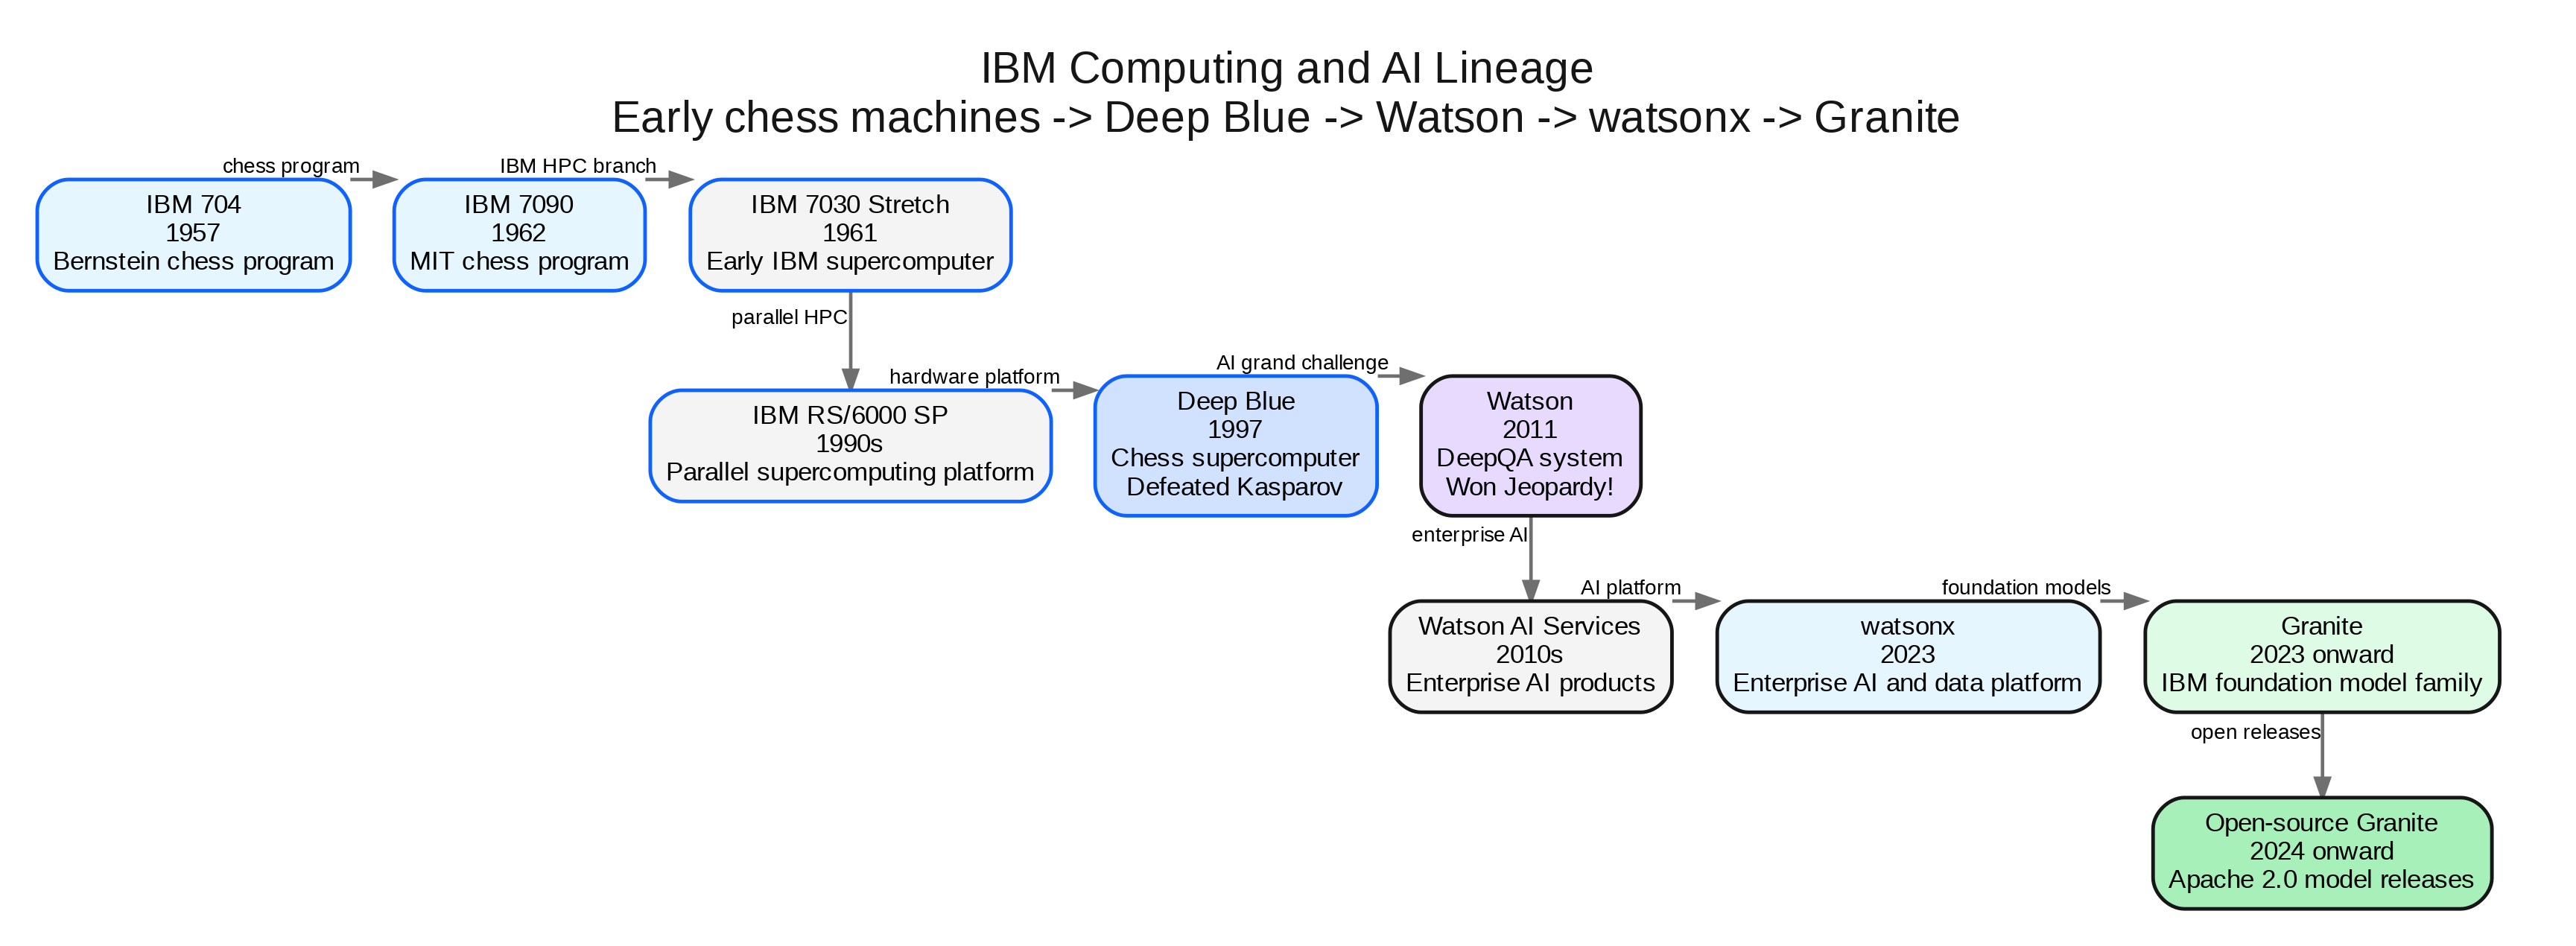

In [17]:
#@title Render a compact serpentine IBM compute lineage flowchart
"""Render a compact IBM lineage flowchart with Graphviz in Google Colab.

The chart follows a serpentine layout so the diagram occupies a small
horizontal footprint while still showing the historical path from early IBM
chess-computing systems to Deep Blue, Watson, watsonx, and Granite.
"""

# =============================================================================
# Imports and dependency repair
# =============================================================================
import os
import shutil
import subprocess
import sys
from pathlib import Path


def run_command(command: list[str]) -> None:
    """Run a command with quiet stdout and visible stderr for diagnostics."""
    env = os.environ.copy()
    env["DEBIAN_FRONTEND"] = "noninteractive"

    subprocess.run(
        command,
        check=True,
        env=env,
        stdout=subprocess.DEVNULL,
    )


if shutil.which("dot") is None:
    try:
        run_command(["apt-get", "-qq", "install", "-y", "graphviz"])
    except subprocess.CalledProcessError:
        run_command(["apt-get", "-qq", "update"])
        run_command(["apt-get", "-qq", "install", "-y", "graphviz"])

try:
    from graphviz import Digraph
except ImportError:
    run_command([sys.executable, "-m", "pip", "-q", "install", "uv"])
    run_command(
        [
            sys.executable,
            "-m",
            "uv",
            "pip",
            "install",
            "--system",
            "-q",
            "graphviz",
        ]
    )
    from graphviz import Digraph

from IPython.display import Image, display

# =============================================================================
# Control knobs
# =============================================================================
OUTPUT_PATH = Path("/content/ibm_serpentine_lineage.png")
WRITE_FILE = True

GRAPH_DPI = "250"
ENGINE = "dot"
RANK_DIRECTION = "TB"

TITLE = "IBM Computing and AI Lineage"
SUBTITLE = "Early chess machines -> Deep Blue -> Watson -> watsonx -> Granite"

IBM_BLUE = "#0F62FE"
IBM_CYAN = "#E5F6FF"
IBM_GREEN = "#DEFBE6"
IBM_PURPLE = "#E8DAFF"
IBM_LIGHT = "#F4F4F4"
IBM_MID = "#D0E2FF"
IBM_DARK = "#161616"
IBM_GRAY = "#6F6F6F"
BORDER = "#8D8D8D"


def add_box(
    graph: Digraph,
    node_id: str,
    label: str,
    fillcolor: str,
    color: str = BORDER,
    fontsize: str = "10",
) -> None:
    """Add a compact styled box node."""
    graph.node(
        node_id,
        label=label,
        shape="box",
        style="rounded,filled",
        fillcolor=fillcolor,
        color=color,
        penwidth="1.4",
        fontname="Helvetica",
        fontsize=fontsize,
        margin="0.09,0.07",
    )


def add_flow_edge(
    graph: Digraph,
    source: str,
    target: str,
    xlabel: str = "",
) -> None:
    """Add a visible flow edge with external text to stabilize routing."""
    graph.edge(
        source,
        target,
        xlabel=xlabel,
        color=IBM_GRAY,
        penwidth="1.35",
        arrowsize="0.75",
        fontname="Helvetica",
        fontsize="8",
    )


def add_invisible_edge(
    graph: Digraph,
    source: str,
    target: str,
    weight: str = "80",
) -> None:
    """Add an invisible high-weight edge to control row order."""
    graph.edge(source, target, style="invis", weight=weight)


def build_flowchart() -> Digraph:
    """Build the compact serpentine IBM lineage chart."""
    graph = Digraph("ibm_lineage_serpentine", format="png", engine=ENGINE)

    graph.attr(
        rankdir=RANK_DIRECTION,
        splines="polyline",
        bgcolor="white",
        pad="0.20",
        nodesep="0.24",
        ranksep="0.46",
        dpi=GRAPH_DPI,
        fontname="Helvetica",
        labelloc="t",
        label=f"{TITLE}\n{SUBTITLE}",
        fontsize="17",
        fontcolor=IBM_DARK,
        outputorder="edgesfirst",
    )

    add_box(
        graph,
        "ibm_704",
        "IBM 704\n1957\nBernstein chess program",
        IBM_CYAN,
        IBM_BLUE,
    )
    add_box(
        graph,
        "ibm_7090",
        "IBM 7090\n1962\nMIT chess program",
        IBM_CYAN,
        IBM_BLUE,
    )
    add_box(
        graph,
        "stretch",
        "IBM 7030 Stretch\n1961\nEarly IBM supercomputer",
        IBM_LIGHT,
        IBM_BLUE,
    )
    add_box(
        graph,
        "rs6000_sp",
        "IBM RS/6000 SP\n1990s\nParallel supercomputing platform",
        IBM_LIGHT,
        IBM_BLUE,
    )
    add_box(
        graph,
        "deep_blue",
        "Deep Blue\n1997\nChess supercomputer\nDefeated Kasparov",
        IBM_MID,
        IBM_BLUE,
    )
    add_box(
        graph,
        "watson",
        "Watson\n2011\nDeepQA system\nWon Jeopardy!",
        IBM_PURPLE,
        IBM_DARK,
    )
    add_box(
        graph,
        "watson_services",
        "Watson AI Services\n2010s\nEnterprise AI products",
        IBM_LIGHT,
        IBM_DARK,
    )
    add_box(
        graph,
        "watsonx",
        "watsonx\n2023\nEnterprise AI and data platform",
        IBM_CYAN,
        IBM_DARK,
    )
    add_box(
        graph,
        "granite",
        "Granite\n2023 onward\nIBM foundation model family",
        IBM_GREEN,
        IBM_DARK,
    )
    add_box(
        graph,
        "granite_open",
        "Open-source Granite\n2024 onward\nApache 2.0 model releases",
        "#A7F0BA",
        IBM_DARK,
    )

    # Row 1 flows left to right.
    with graph.subgraph(name="rank_row_1") as row:
        row.attr(rank="same")
        add_invisible_edge(row, "ibm_704", "ibm_7090")
        add_invisible_edge(row, "ibm_7090", "stretch")

    # Row 2 flows right to left, so the physical order is reversed.
    with graph.subgraph(name="rank_row_2") as row:
        row.attr(rank="same")
        add_invisible_edge(row, "watson", "deep_blue")
        add_invisible_edge(row, "deep_blue", "rs6000_sp")

    # Row 3 flows left to right.
    with graph.subgraph(name="rank_row_3") as row:
        row.attr(rank="same")
        add_invisible_edge(row, "watson_services", "watsonx")
        add_invisible_edge(row, "watsonx", "granite")

    # Row 4 keeps the open-source release beneath Granite.
    with graph.subgraph(name="rank_row_4") as row:
        row.attr(rank="same")
        add_invisible_edge(row, "granite_open", "granite_open")

    # Visible flow follows the serpentine physical order.
    add_flow_edge(graph, "ibm_704", "ibm_7090", "chess program")
    add_flow_edge(graph, "ibm_7090", "stretch", "IBM HPC branch")
    add_flow_edge(graph, "stretch", "rs6000_sp", "parallel HPC")
    add_flow_edge(graph, "rs6000_sp", "deep_blue", "hardware platform")
    add_flow_edge(graph, "deep_blue", "watson", "AI grand challenge")
    add_flow_edge(graph, "watson", "watson_services", "enterprise AI")
    add_flow_edge(graph, "watson_services", "watsonx", "AI platform")
    add_flow_edge(graph, "watsonx", "granite", "foundation models")
    add_flow_edge(graph, "granite", "granite_open", "open releases")

    return graph


flowchart = build_flowchart()
png_bytes = flowchart.pipe(format="png")

if WRITE_FILE:
    OUTPUT_PATH.write_bytes(png_bytes)
    print(f"Saved PNG to: {OUTPUT_PATH}")

display(Image(data=png_bytes))